First 5 Records:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-n

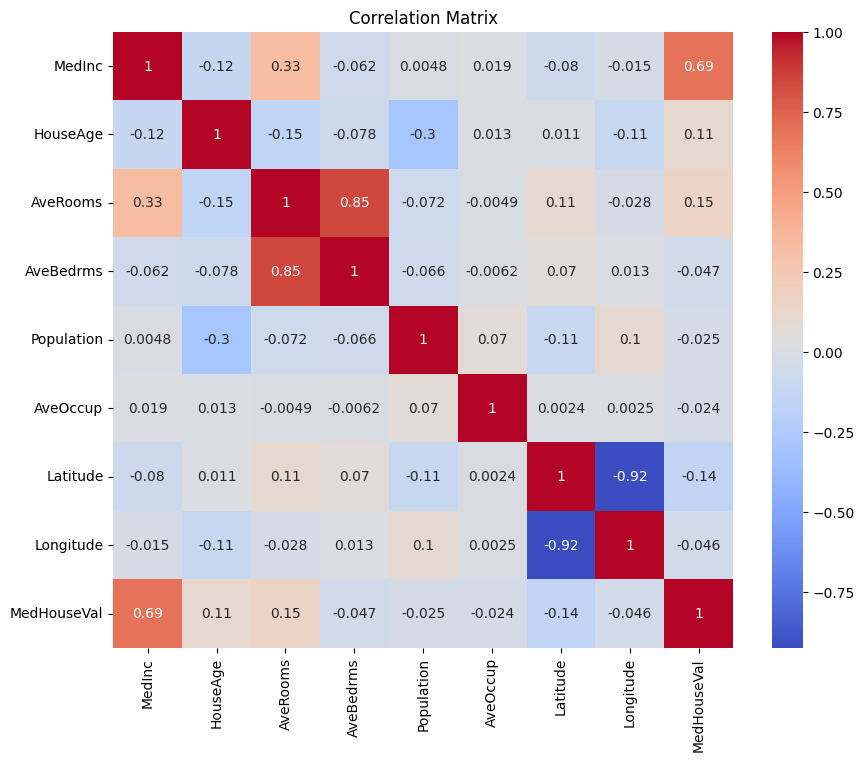


Model Training Completed!

Model Performance
MAE  : 0.533
RMSE : 0.746
R²   : 0.576


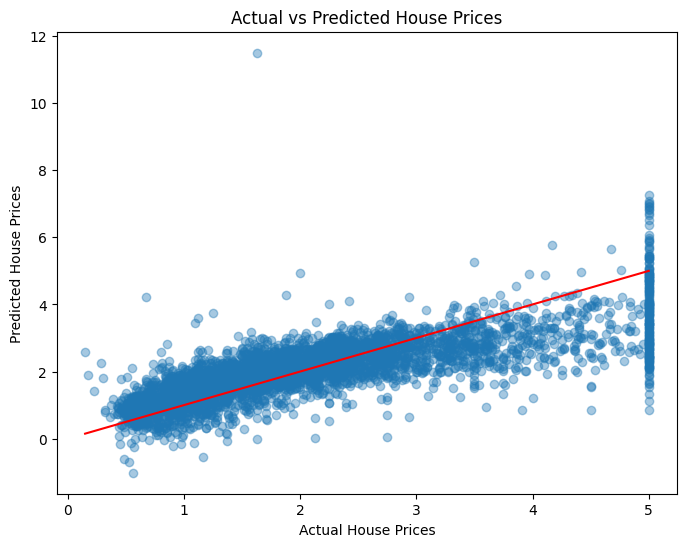

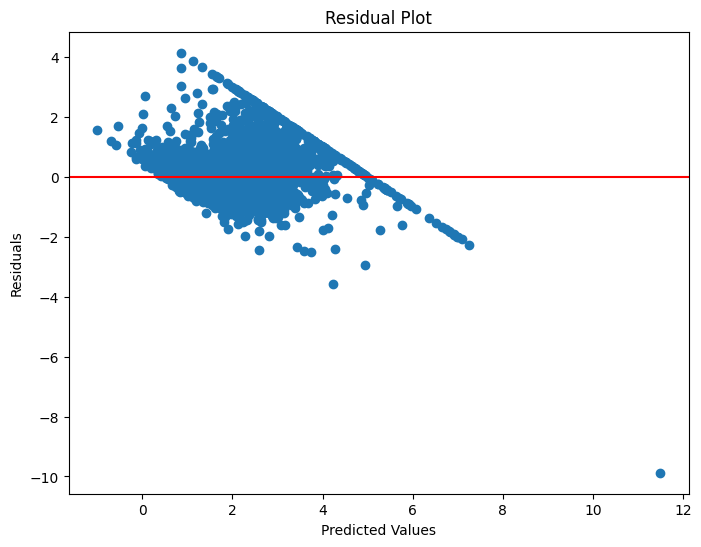


Model saved successfully as 'house_price_model.pkl'


In [1]:
# =====================================================
# HOUSE PRICE PREDICTION USING LINEAR REGRESSION
# California Housing Dataset
# =====================================================

# Import libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import dataset and machine learning modules
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================
# STEP 1: LOAD THE DATASET
# =====================================================

# Load California Housing dataset from Scikit-Learn
data = fetch_california_housing(as_frame=True)

# Combine feature columns and target column into a single DataFrame
df = pd.concat(
    [data.data, data.target.rename('MedHouseVal')],
    axis=1
)

# Display first 5 rows of dataset
print("First 5 Records:")
print(df.head())

# =====================================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================

# Display dataset information such as
# number of rows, columns and data types
print("\nDataset Information:")
print(df.info())

# Generate statistical summary
# (mean, min, max, standard deviation etc.)
print("\nStatistical Summary:")
print(df.describe())

# Check for missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

# =====================================================
# STEP 3: CORRELATION ANALYSIS
# =====================================================

# Plot correlation heatmap to understand
# relationships between features
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,      # Show correlation values
    cmap='coolwarm'  # Color scheme
)

plt.title("Correlation Matrix")
plt.show()

# =====================================================
# STEP 4: FEATURE SELECTION
# =====================================================

# Input features (Independent Variables)
X = df.drop(columns='MedHouseVal')

# Target variable (Dependent Variable)
y = df['MedHouseVal']

# =====================================================
# STEP 5: SPLIT DATA INTO TRAINING AND TESTING SETS
# =====================================================

# 80% data used for training
# 20% data used for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# STEP 6: TRAIN LINEAR REGRESSION MODEL
# =====================================================

# Create Linear Regression model object
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)

print("\nModel Training Completed!")

# =====================================================
# STEP 7: MAKE PREDICTIONS
# =====================================================

# Predict house prices for test data
y_pred = model.predict(X_test)

# =====================================================
# STEP 8: EVALUATE MODEL PERFORMANCE
# =====================================================

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R-Squared Score (R²)
r2 = r2_score(y_test, y_pred)

# Display evaluation metrics
print("\nModel Performance")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

# =====================================================
# STEP 9: ACTUAL VS PREDICTED VALUES
# =====================================================

# Scatter plot comparing actual values
# with predicted values
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

# Plot ideal prediction line
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='red'
)

plt.show()

# =====================================================
# STEP 10: RESIDUAL ANALYSIS
# =====================================================

# Residual = Actual Value - Predicted Value
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals
)

# Reference line showing zero error
plt.axhline(
    y=0,
    color='red'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# =====================================================
# STEP 11: SAVE TRAINED MODEL (OPTIONAL)
# =====================================================

import pickle

# Save trained model into a .pkl file
with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("\nModel saved successfully as 'house_price_model.pkl'")